# Week 7 · Day 1 — Class: Your First Charts with Matplotlib & Seaborn

Welcome to Week 7! So far you have loaded, cleaned, and explored data.
Today you learn to **turn that data into pictures**.

A good chart shows a pattern in one second that a table of numbers hides.
By the end of this class you will be able to make line, bar, scatter, and histogram
plots, label them properly, and make them look good with Seaborn.

**Dataset:** Gapminder — life expectancy, population, and income for 142 countries
from 1952 to 2007. The data is already clean, so today we focus only on plotting.


## 1. Setup

We import three tools:

- `pandas` to hold the data
- `matplotlib.pyplot` to draw charts (we call it `plt`)
- `seaborn` to make charts prettier with less code (we call it `sns`)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# A clean default style for all our charts
sns.set_theme(style="whitegrid")

print("Ready to plot!")

Ready to plot!


## 2. Load the data

We read the Gapminder CSV into a DataFrame and take a first look.

In [2]:
df = pd.read_csv("data/gapminder.csv")

print("Rows and columns:", df.shape)
df.head()

Rows and columns: (1704, 6)


,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106


Each row is one country in one year. The columns are:

- `country` — the country name
- `year` — the year (every 5 years, 1952 to 2007)
- `pop` — population
- `continent` — which continent the country is in
- `lifeExp` — life expectancy in years
- `gdpPercap` — income per person (GDP per capita)


## 3. Why visualize?

Look at these numbers for one country. Can you *feel* the trend?

In [3]:
afg = df[df["country"] == "Afghanistan"]
print(afg[["year", "lifeExp"]].to_string(index=False))

 year  lifeExp
 1952   28.801
 1957   30.332
 1962   31.997
 1967   34.020
 1972   36.088
 1977   38.438
 1982   39.854
 1987   40.822
 1992   41.674
 1997   41.763
 2002   42.129
 2007   43.828


The numbers go up, but slowly. Now let's **see** it as a line.

In [4]:
afg.head()

,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106


In [5]:
afg['year']

0     1952
1     1957
2     1962
3     1967
4     1972
5     1977
6     1982
7     1987
8     1992
9     1997
10    2002
11    2007
Name: year, dtype: int64

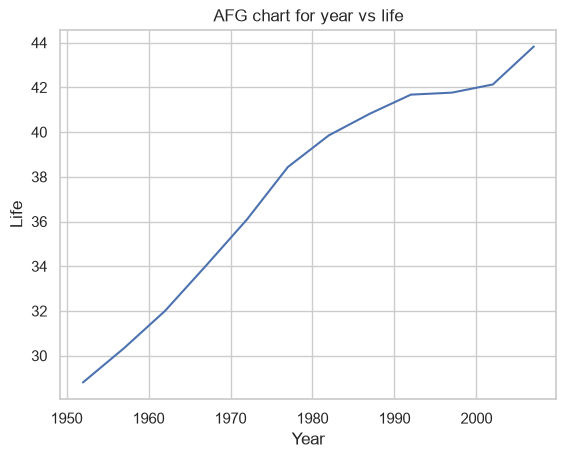

In [ ]:
plt.plot(afg["year"], afg["lifeExp"])
plt.title("AFG chart for year vs life")
plt.xlabel("Year")
plt.ylabel("Life")
plt.show()

Much clearer! But this chart has no title and no labels. Nobody knows what it shows. Let's fix that next.

## 4. Line plot — done properly

A line plot is best for showing a **trend over time**.
Every chart you share should have:

- a **title** (what is this?)
- an **x-axis label** and **y-axis label** (what do the numbers mean?)


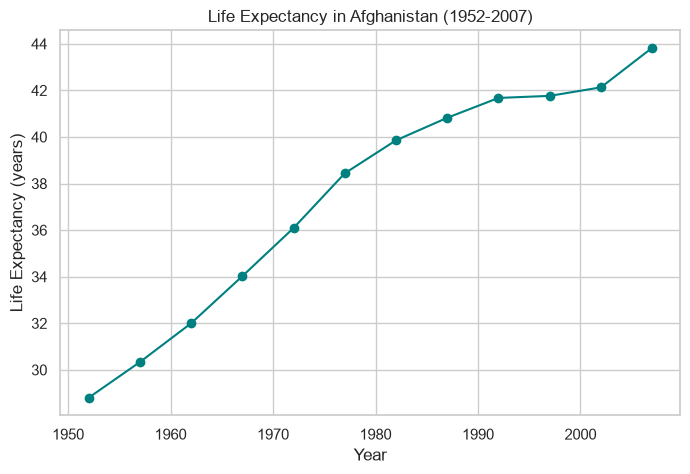

In [13]:
plt.figure(figsize=(8, 5))          # width, height in inches
plt.plot(afg["year"], afg["lifeExp"], marker="o", color="teal")

plt.title("Life Expectancy in Afghanistan (1952-2007)")
plt.xlabel("Year")
plt.ylabel("Life Expectancy (years)")
plt.show()

In [10]:
afg

,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106
5,Afghanistan,1977,14880372.0,Asia,38.438,786.113360
6,Afghanistan,1982,12881816.0,Asia,39.854,978.011439
7,Afghanistan,1987,13867957.0,Asia,40.822,852.395945
8,Afghanistan,1992,16317921.0,Asia,41.674,649.341395
9,Afghanistan,1997,22227415.0,Asia,41.763,635.341351


**Your turn to read it:** life expectancy rose from about 29 years to about 44 years over 55 years. The chart makes that story obvious.

## 5. Bar plot — comparing groups

A bar plot is best for **comparing categories**.
Let's compare average life expectancy per continent in the year 2007.

First we filter to 2007, then group by continent and take the mean.

In [14]:
df_2007 = df[df["year"] == 2007]

continent_life = df_2007.groupby("continent")["lifeExp"].mean()
print(continent_life.round(1))

continent
Africa      54.8
Americas    73.6
Asia        70.7
Europe      77.6
Oceania     80.7
Name: lifeExp, dtype: float64


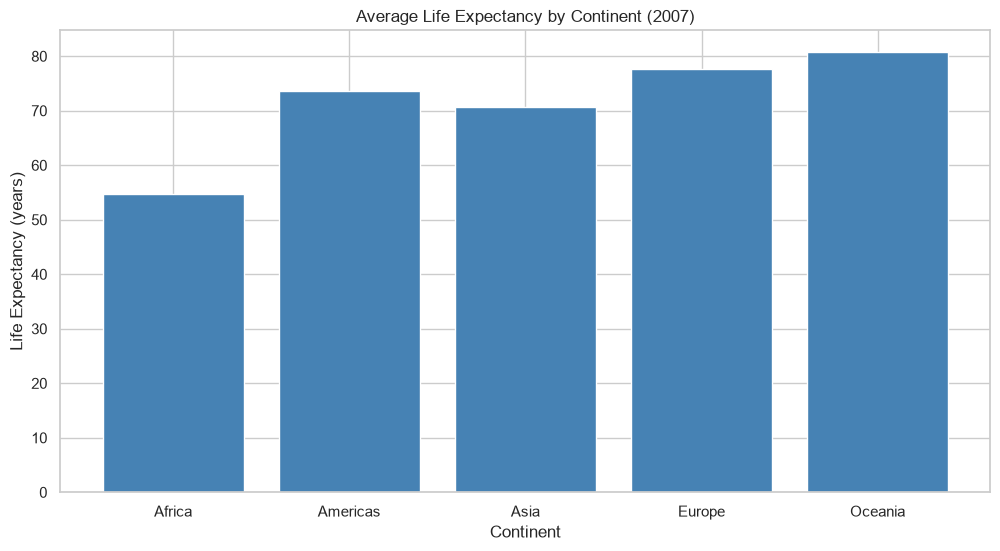

In [16]:
plt.figure(figsize=(12, 6))
plt.bar(continent_life.index, continent_life.values, color="steelblue")

plt.title("Average Life Expectancy by Continent (2007)")
plt.xlabel("Continent")
plt.ylabel("Life Expectancy (years)")
plt.show()

At a glance: Oceania and Europe are highest; Africa is clearly the lowest. That is the power of a bar chart.

## 6. Scatter plot — showing a relationship

A scatter plot shows the **relationship between two numbers**.
Does having more income (`gdpPercap`) go with living longer (`lifeExp`)?
Each dot is one country in 2007.

In [17]:
df_2007

,country,year,pop,continent,lifeExp,gdpPercap
11,Afghanistan,2007,31889923.0,Asia,43.828,974.580338
23,Albania,2007,3600523.0,Europe,76.423,5937.029526
35,Algeria,2007,33333216.0,Africa,72.301,6223.367465
47,Angola,2007,12420476.0,Africa,42.731,4797.231267
59,Argentina,2007,40301927.0,Americas,75.320,12779.379640
...,...,...,...,...,...,...
1655,Vietnam,2007,85262356.0,Asia,74.249,2441.576404
1667,West Bank and Gaza,2007,4018332.0,Asia,73.422,3025.349798
1679,"Yemen, Rep.",2007,22211743.0,Asia,62.698,2280.769906
1691,Zambia,2007,11746035.0,Africa,42.384,1271.211593


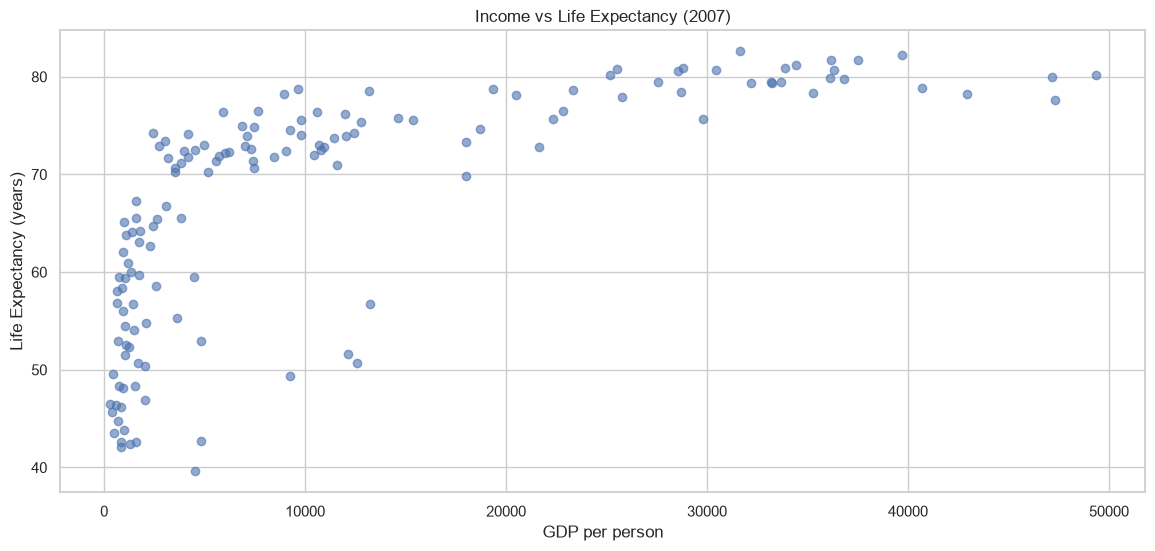

In [18]:
plt.figure(figsize=(14, 6))
plt.scatter(df_2007["gdpPercap"], df_2007["lifeExp"], alpha=0.6)

plt.title("Income vs Life Expectancy (2007)")
plt.xlabel("GDP per person")
plt.ylabel("Life Expectancy (years)")
plt.show()

The dots climb from bottom-left to top-right: richer countries tend to live longer. The rise is steep at first, then flattens.

## 7. Histogram — showing a distribution

A histogram shows **how one number is spread out**.
It puts values into bins and counts how many fall in each bin.
Let's see the spread of life expectancy across all countries in 2007.

In [20]:
df_2007.head()

,country,year,pop,continent,lifeExp,gdpPercap
11,Afghanistan,2007,31889923.0,Asia,43.828,974.580338
23,Albania,2007,3600523.0,Europe,76.423,5937.029526
35,Algeria,2007,33333216.0,Africa,72.301,6223.367465
47,Angola,2007,12420476.0,Africa,42.731,4797.231267
59,Argentina,2007,40301927.0,Americas,75.320,12779.379640


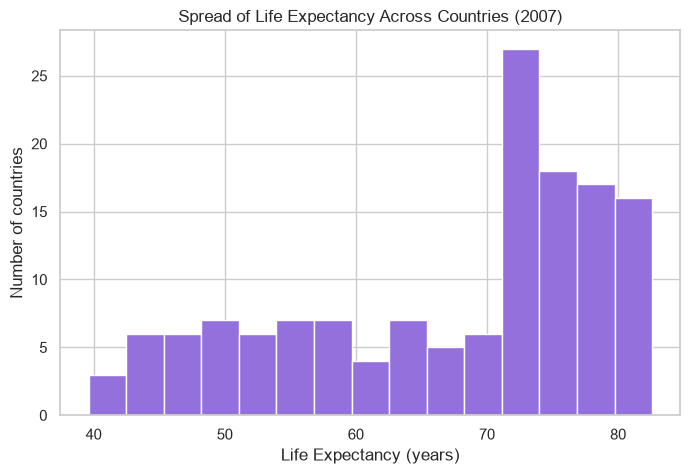

In [19]:
plt.figure(figsize=(8, 5))
plt.hist(df_2007["lifeExp"], bins=15, color="mediumpurple", edgecolor="white")

plt.title("Spread of Life Expectancy Across Countries (2007)")
plt.xlabel("Life Expectancy (years)")
plt.ylabel("Number of countries")
plt.show()

Most countries cluster around 70-80 years, but a group sits far lower near 40-55 — those are mostly African countries we saw in the bar chart.

## 8. The same charts with Seaborn

Seaborn is built on top of Matplotlib. It makes nicer charts with **less code**
and understands DataFrames directly — you pass the column *names* and the `data`.

Watch how short these are.

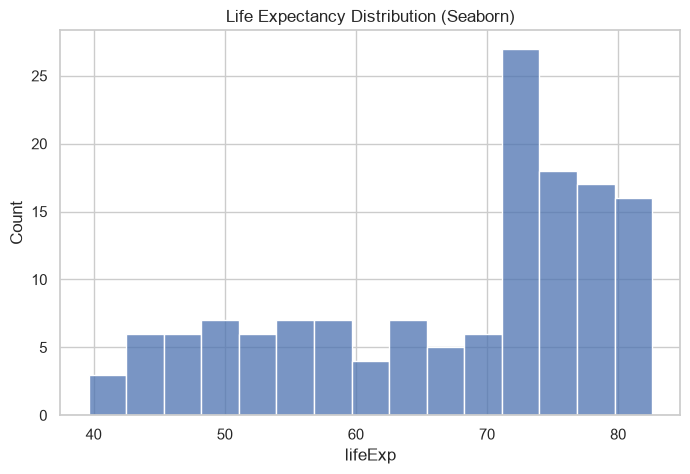

In [21]:
# Seaborn histogram
plt.figure(figsize=(8, 5))
sns.histplot(data=df_2007, x="lifeExp", bins=15)
plt.title("Life Expectancy Distribution (Seaborn)")
plt.show()

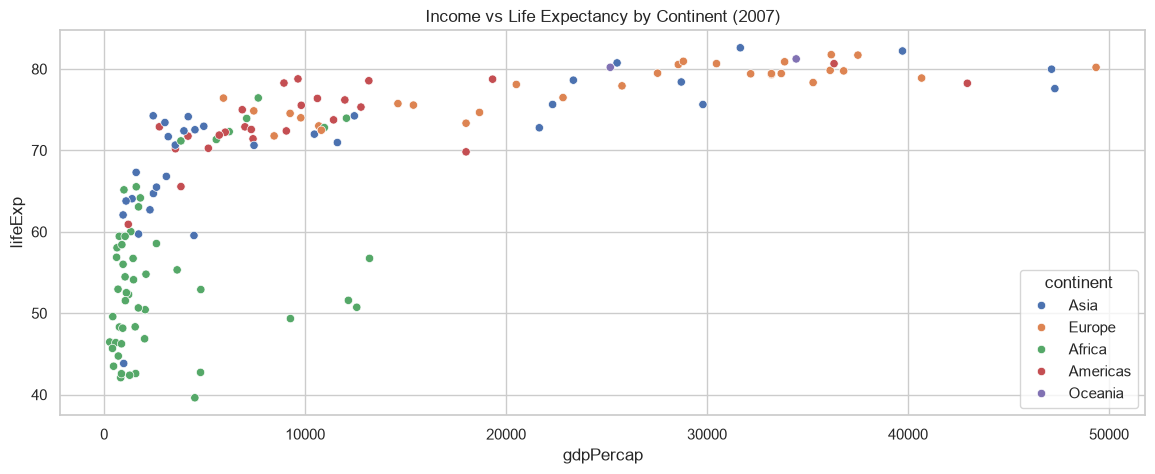

In [25]:
# Seaborn scatter - and we can COLOR by continent for free!
plt.figure(figsize=(14, 5))
sns.scatterplot(data=df_2007, x="gdpPercap", y="lifeExp", hue="continent")
plt.title("Income vs Life Expectancy by Continent (2007)")
plt.show()

That `hue="continent"` line coloured every dot by its continent and added a legend automatically.
Now the story is even richer: the low-income, low-life-expectancy corner is mostly African countries,
while Europe sits top-right. This is why we love Seaborn.

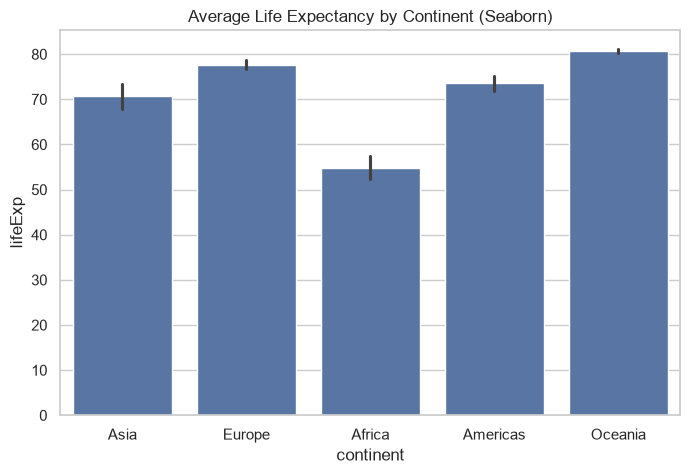

In [28]:
# Seaborn bar plot - it computes the average for us
plt.figure(figsize=(8, 5))
sns.barplot(data=df_2007, x="continent", y="lifeExp")
plt.title("Average Life Expectancy by Continent (Seaborn)")
plt.show()

## 9. Recap

Today you learned to:

- Make **line** plots for trends over time
- Make **bar** plots to compare groups
- Make **scatter** plots to show relationships
- Make **histograms** to show distributions
- Always add a **title, x-label, and y-label**
- Use **Seaborn** for prettier charts with less code, including `hue` to colour by a group

**Choosing a chart (quick guide):**

| Question | Chart |
|----------|-------|
| How did it change over time? | Line |
| Which group is bigger? | Bar |
| Are two numbers related? | Scatter |
| How is one number spread out? | Histogram |

Next class: practice choosing the right chart, then meet **Streamlit** to put charts on a web page.
